In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.interpolate import griddata
import requests
import math
import time
from io import StringIO
import os
from datetime import datetime, timezone

In [2]:
NASA_POWER_API_URL = "https://power.larc.nasa.gov/api/temporal/daily/point?parameters={parameters}&community=RE&longitude={lon}&latitude={lat}&start={start}&end={end}&format=CSV"
NASA_POWER_BATCH_SIZE = 10
NASA_MISSING_VALUE = -999

UGANDA_SHAPEFILE = "Data/gadm41_UGA_shp/gadm41_UGA_0.shp"
OUTPUT_FILENAME = 'uganda_ghi_heatmap.png'
GHI_PARAMETER = 'ALLSKY_SFC_SW_DWN'
START_DATE= '2021-01-01'
END_DATE = '2021-12-31'
GRID_SPACING_DEGREES = 0.1  # Adjust this value to change the grid spacing
INTERPORATION_METHOD = 'nearest'  # 'linear', 'nearest', or 'cubic'
COLOR_MAP = 'YlOrRd'

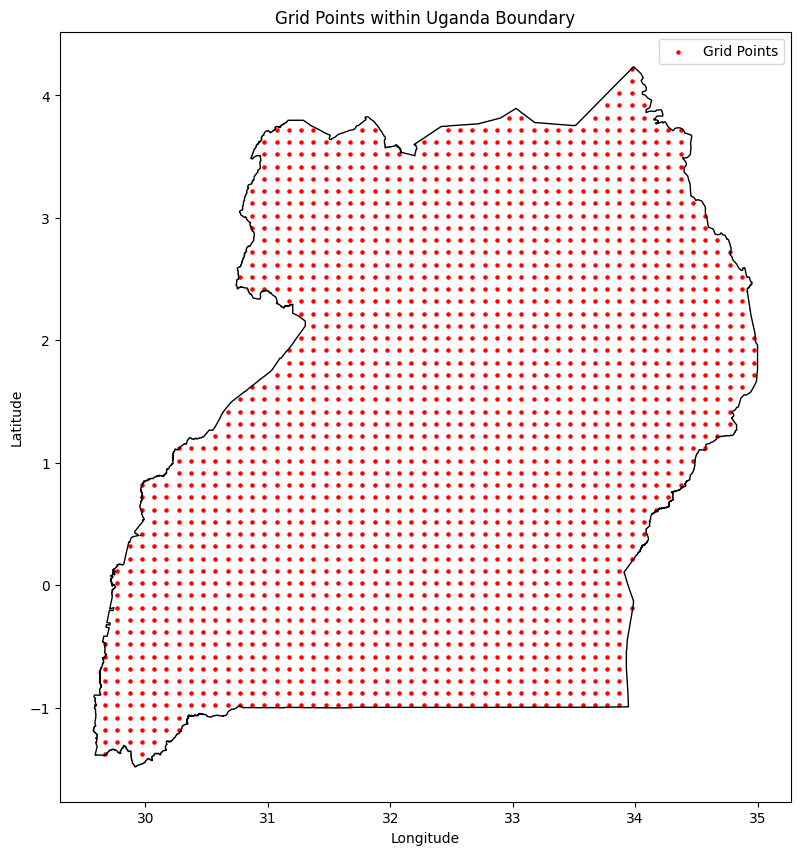

In [8]:
uganda_map = gpd.read_file(UGANDA_SHAPEFILE)
uganda_map = uganda_map.to_crs(epsg=4326)  # Convert to WGS84
uganda_boundary = uganda_map.union_all() 
uganda_boundary = uganda_boundary.buffer(0)  # Fix geometry issues

minx, miny, maxx, maxy = uganda_boundary.bounds

# Create a grid of points within the Uganda boundary
lon_grid = np.arange(minx, maxx, GRID_SPACING_DEGREES)
lat_grid = np.arange(miny, maxy, GRID_SPACING_DEGREES)
lons, lats = np.meshgrid(lon_grid, lat_grid)
grid_points = [(lon, lat) for lon, lat in zip(lons.flatten(), lats.flatten())]

# Filter grid points to only include those within the Uganda boundary
grid_point_objects = [Point(lon, lat) for lon, lat in grid_points]
grid_gdf = gpd.GeoDataFrame(geometry=grid_point_objects, crs=uganda_map.crs)
grid_gdf = grid_gdf[grid_gdf.within(uganda_boundary)]

# Prepare location data for NASA POWER API
locations = {}

for i, point in grid_gdf.iterrows():
    loc_name = f"point_{i}"
    locations[loc_name] = {
        'lat': point.geometry.y,
        'lon': point.geometry.x,
        'Start Time': START_DATE,
        'End Time' : END_DATE
    }
    
# plot the Uganda map indicating the grid points
fig, ax = plt.subplots(figsize=(10, 10))
uganda_map.boundary.plot(ax=ax, color='black', linewidth=1)
grid_gdf.plot(ax=ax, color='red', markersize=5, label='Grid Points')
plt.title('Grid Points within Uganda Boundary')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

In [9]:
# Extract coordinates array for points within Uganda boundary
uganda_coordinates = [(point.geometry.x, point.geometry.y) for _, point in grid_gdf.iterrows()]
print(f"Number of coordinates within Uganda boundary: {len(uganda_coordinates)}")
print("First 10 coordinates:")
for i, coord in enumerate(uganda_coordinates[:10]):
    print(f"  {i+1}: {coord}")

Number of coordinates within Uganda boundary: 1962
First 10 coordinates:
  1: (29.671499001000008, -1.3821398259999795)
  2: (29.971499001000012, -1.3821398259999795)
  3: (29.671499001000008, -1.2821398259999794)
  4: (29.77149900100001, -1.2821398259999794)
  5: (29.87149900100001, -1.2821398259999794)
  6: (29.971499001000012, -1.2821398259999794)
  7: (30.071499001000014, -1.2821398259999794)
  8: (29.671499001000008, -1.1821398259999794)
  9: (29.77149900100001, -1.1821398259999794)
  10: (29.87149900100001, -1.1821398259999794)


In [13]:
# --- CAMS Download Configuration ---

# CAMS data is in UTC. It's best to use timezone-aware datetimes.
# For this example, we will download data for a single day.
start_date = datetime(2024, 1, 1, tzinfo=timezone.utc)
end_date = datetime(2024, 12, 31, 23, 59, 59, tzinfo=timezone.utc)

# Time step must be an ISO 8601 duration string. 'PT1H' means 1-hour intervals.
time_step = '1d'
print(f"Fetching data for the period: {start_date.date()} -> {end_date.date()} (UTC)")
print(f"Time step: {time_step} (1 hour)")

Fetching data for the period: 2024-01-01 -> 2024-12-31 (UTC)
Time step: 1d (1 hour)


In [14]:
# --- Main Logic to Perform Grid Download ---
from susse import CAMSClient
# 1. Initialize the CAMSClient
# This will handle getting your CAMS-registered email.
client = CAMSClient()

# 2. Create a list to store the DataFrames from all grid points
all_dataframes = []

print("-" * 40)

# 3. Loop through each grid point and download the data
for i, point in enumerate(uganda_coordinates[:3]):  # Limiting to first 3 points for demonstration
    lon, lat = point
    print(f"\nProcessing grid point {i+1}/{len(uganda_coordinates)}: (Lat={lat:.2f}, Lon={lon:.2f})")

    # Fetch the data using the client's method
    result = client.fetch_data(
        latitude=lat,
        longitude=lon,
        start=start_date,
        end=end_date,
        time_step=time_step,
    )

    # The client returns a dictionary with an 'error' key. Check it first.
    if result["error"]:
        print(f"  \u2717 FAILED. An error occurred: {result['error']}")
    else:
        # The data is in a list of records under the 'data' key
        df = pd.DataFrame(result["data"])
        
        # Add location info to the DataFrame
        df['latitude'] = lat
        df['longitude'] = lon
        
        all_dataframes.append(df)
        print(f"  \u2713 Success! Fetched {len(df)} hourly records.")

    # It's good practice to add a small delay between API requests
    time.sleep(1)

print(f"\n{'-'*40}\nDownload complete.")
print(f"Successfully processed {len(all_dataframes)} out of {len(grid_points)} grid points.")


----------------------------------------

Processing grid point 1/1962: (Lat=-1.38, Lon=29.67)
  ✓ Success! Fetched 366 hourly records.
  ✓ Success! Fetched 366 hourly records.

Processing grid point 2/1962: (Lat=-1.38, Lon=29.97)

Processing grid point 2/1962: (Lat=-1.38, Lon=29.97)
  ✓ Success! Fetched 366 hourly records.
  ✓ Success! Fetched 366 hourly records.

Processing grid point 3/1962: (Lat=-1.28, Lon=29.67)

Processing grid point 3/1962: (Lat=-1.28, Lon=29.67)
  ✓ Success! Fetched 366 hourly records.
  ✓ Success! Fetched 366 hourly records.

----------------------------------------
Download complete.
Successfully processed 3 out of 3190 grid points.

----------------------------------------
Download complete.
Successfully processed 3 out of 3190 grid points.


In [45]:
ghi_data[GHI_PARAMETER] = pd.to_numeric(ghi_data[GHI_PARAMETER], errors='coerce')
ghi_data[GHI_PARAMETER] = ghi_data[GHI_PARAMETER].replace(NASA_MISSING_VALUE, np.nan)

# Calculate the mean GHI for each grid point
mean_ghi = ghi_data.groupby(['location', 'latitude', 'longitude'])[GHI_PARAMETER].mean().reset_index()
mean_ghi = mean_ghi.rename(columns={GHI_PARAMETER: 'mean_ghi'})
mean_ghi = mean_ghi.dropna(subset=['mean_ghi'])

In [46]:
# interpolate the GHI values onto the grid
# Create a grid of points for interpolation
interp_lon = np.linspace(minx, maxx, int((maxx - minx) / GRID_SPACING_DEGREES) + 1)
interp_lat = np.linspace(miny, maxy, int((maxy - miny) / GRID_SPACING_DEGREES) + 1)
interp_lons, interp_lats = np.meshgrid(interp_lon, interp_lat)

# prepare the data for interpolation
known_points = mean_ghi[['longitude', 'latitude']].values
known_values = mean_ghi['mean_ghi'].values
target_points = np.vstack((interp_lons.ravel(), interp_lats.ravel())).T

# Perform the interpolation
interpolated_ghi = griddata(known_points, known_values, target_points, method=INTERPORATION_METHOD)

# Reshape the interpolated data to match the grid shape
interpolated_ghi = interpolated_ghi.reshape(interp_lons.shape)

# Create points for masking
interp_points = [Point(lon, lat) for lon, lat in zip(interp_lons.ravel(), interp_lats.ravel())]
interp_gdf = gpd.GeoDataFrame(geometry=interp_points, crs=uganda_map.crs)

# Create mask using contains operation
mask = np.array([uganda_boundary.contains(point) for point in interp_gdf.geometry])
mask = mask.reshape(interp_lons.shape)

# Apply the mask to the interpolated data
interpolated_ghi_masked = np.where(mask, interpolated_ghi, np.nan)



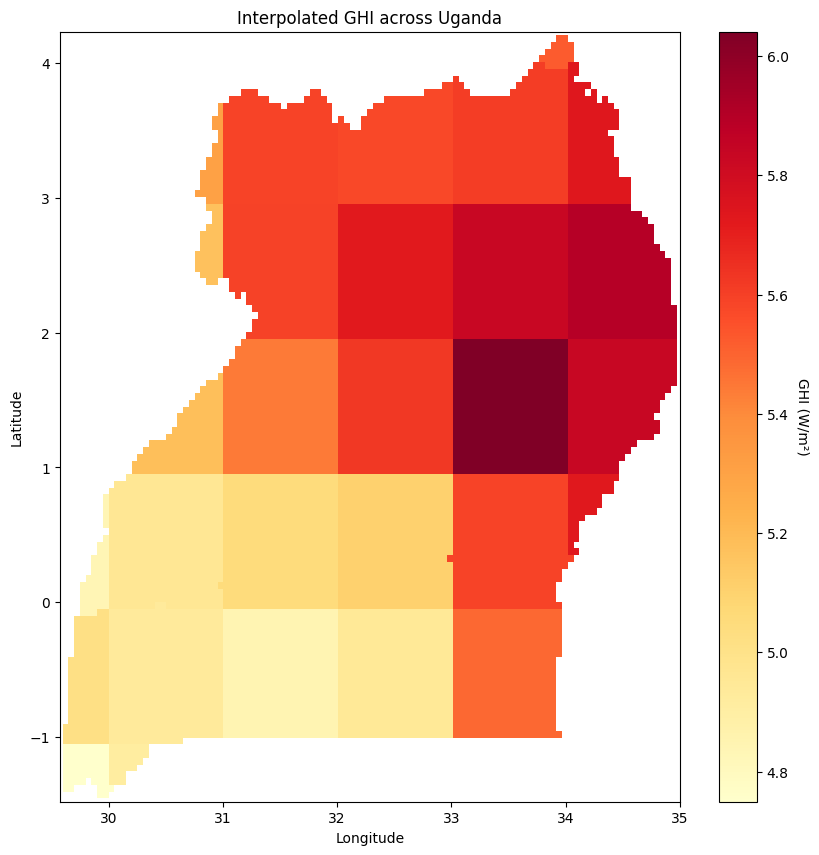

In [48]:
# visualize the results
fig, ax = plt.subplots(figsize=(10, 10))

c = ax.pcolormesh(interp_lons, interp_lats, interpolated_ghi_masked, shading='auto', cmap=COLOR_MAP)
cbar = plt.colorbar(c, ax=ax, orientation='vertical')
cbar.set_label('GHI (W/m²)', rotation=270, labelpad=15)
plt.title('Interpolated GHI across Uganda')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(minx, maxx)
plt.ylim(miny, maxy)
# plt.grid()
# plt.savefig(OUTPUT_FILENAME, dpi=300, bbox_inches='tight')
plt.show()